# Idea
load tcsv model(s) and test them on all subsets and inverse subsets

In [1]:
import os
# os.nice(19)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib
import re

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
m = 15

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Models

In [4]:
from pathlib import Path
import re
import joblib

MODEL_DIR = find_repo_root() / Path("Analysis/modeling/tscv_models")

pipelines = {}

# pattern:
# tscv_MultiTaskLasso_{target}_pipeline_{alpha}_{number}.pkl
pattern = re.compile(
    r'tscv_MultiTaskLasso_'
    r'(?P<target>.+?)_pipeline_'
    r'(?P<alpha>\d+p\d+)_'
    r'(?P<number>[A-Za-z0-9]+)\.pkl'
)

# --- collect and sort files deterministically ---
pkl_files = []

for pkl_file in MODEL_DIR.glob("*.pkl"):
    match = pattern.match(pkl_file.name)
    if not match:
        continue

    target = match.group("target")
    alpha = float(match.group("alpha").replace("p", "."))
    number = match.group("number")  # string, e.g. "1", "1i"

    pkl_files.append((target, number, alpha, pkl_file))

# sort by target, number, alpha
pkl_files.sort(key=lambda x: (x[0], x[1], x[2]))

# --- load pipelines ---
for target, number, alpha, pkl_file in pkl_files:
    pipelines.setdefault(target, {}).setdefault(number, {})[alpha] = (
        joblib.load(pkl_file)
    )

print(f"✅ Successfully loaded pipelines for targets: {list(pipelines.keys())}")

✅ Successfully loaded pipelines for targets: ['trend']


Remove unwanted pipelines (depend on the sampling rate)

In [9]:
# remove pipeline with number '14' if exists
if '14' in pipelines.get(target, {}):
    del pipelines[target]['14']
    print("Removed pipeline with number '14' due to known issues.")

Removed pipeline with number '14' due to known issues.


Show all loaded pipelines

In [10]:
for target in pipelines.keys():
    print(f"Target: {target}")
    for number in pipelines[target].keys():
        alphas = list(pipelines[target][number].keys())
        print(f"  Number: {number}, Alphas: {alphas}")

Target: trend
  Number: 1, Alphas: [0.05, 0.075, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
  Number: 1i, Alphas: [0.05, 0.1]
  Number: 3, Alphas: [0.05, 0.1, 0.25, 0.5, 1.0, 5.0]
  Number: 4, Alphas: [0.02, 0.05, 0.1, 0.5, 1.0, 5.0]
  Number: 4i, Alphas: [0.1, 0.5]


# Subsets

In [24]:
Subset_DIR = find_repo_root() / Path("Analysis/Subsets")
# 'subsets_Kp.csv'  # 'subsets_eflag.csv'  # 'subsets_meanstd.csv' # 'subsets_merged.csv'
intervals_1 = pd.read_csv(Subset_DIR / Path('subsets_eflag_meanstd.csv'))
intervals_4 = pd.read_csv(Subset_DIR / Path('subsets_Kp.csv'))

# create masks
mask_1 = pd.Series(False, index=GFOC_data.index)
for _, row in intervals_1.iterrows():
    mask_1 |= (GFOC_data.index >= row["start"]) & (GFOC_data.index <= row["end"])
mask_4 = pd.Series(False, index=GFOC_data.index)
for _, row in intervals_4.iterrows():
    mask_4 |= (GFOC_data.index >= row["start"]) & (GFOC_data.index <= row["end"])

# inverted masks
inv_mask_1 = ~mask_1
inv_mask_4 = ~mask_4

# all data masks
all_mask = pd.Series(True, index=GFOC_data.index)

masks = {
    'subset_1': mask_1,
    'subset_4': mask_4,
    'subset_1_inv': inv_mask_1,
    'subset_4_inv': inv_mask_4,
    'subset_3': all_mask
}

# Run Pipelines

In [25]:
predictions = {}
r2_values = {}

for target in pipelines.keys():
    for number in pipelines[target].keys():
        for alpha, pipeline in pipelines[target][number].items():
            # predict
            for mask_name, mask in masks.items():
                # create active mask for test set
                active_test = GFOC_data[mask].index.intersection(X_test.index)
                active_mask = X_test.index.isin(active_test)

                y_test_pred = pd.DataFrame(
                    pipeline.predict(X_test[active_mask]),
                    index=X_test.index[active_mask],
                    columns=y_test.columns
                )

                # calculate R2 values
                r2 = r2_score(
                    y_test[active_mask],
                    y_test_pred
                )

                # store predictions and R2 values
                predictions.setdefault(target, {}) \
                           .setdefault(number, {}) \
                           .setdefault(mask_name, {})[alpha] = y_test_pred
                r2_values.setdefault(target, {}) \
                         .setdefault(number, {}) \
                         .setdefault(mask_name, {})[alpha] = r2
                

# Plot

In [28]:
def plot_r2_bars(r2_values, target, alpha):
    numbers = sorted(r2_values[target].keys())

    # Collect all mask names across numbers
    mask_names = sorted({
        mask
        for number in numbers
        for mask in r2_values[target][number]
        if alpha in r2_values[target][number][mask]
    })

    n_masks = len(mask_names)
    n_numbers = len(numbers)

    x = np.arange(n_masks)
    width = 0.8 / n_numbers  # total bar width per mask

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, number in enumerate(numbers):
        r2_vals = [
            r2_values[target][number][mask].get(alpha, np.nan)
            for mask in mask_names
        ]

        ax.bar(
            x + i * width,
            r2_vals,
            width,
            label=f"number={number}"
        )

    ax.set_xticks(x + width * (n_numbers - 1) / 2)
    ax.set_xticklabels(mask_names, rotation=45)
    colors = plt.cm.tab10(range(len(mask_names)))
    for tick, color in zip(ax.get_xticklabels(), colors):
        tick.set_color(color)
    ax.set_ylabel("R²")
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Mask")
    ax.set_title(f"R² values for target={target}, alpha={alpha}")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.legend(loc='upper center', ncol=n_numbers)
    fig.tight_layout()
    plt.show()


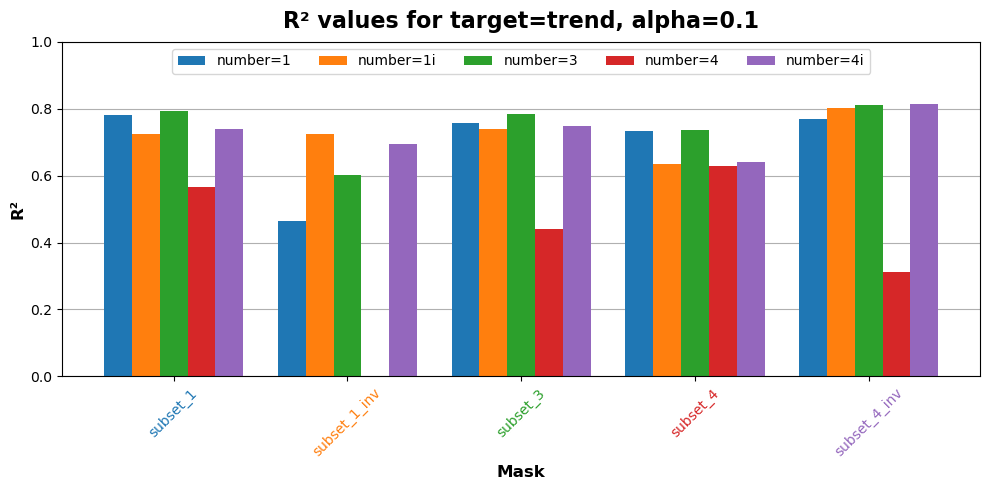

In [29]:
plot_r2_bars(
    r2_values,
    target="trend",
    alpha=0.1
)

# Observations
The R2 value for '4' is the lowest for all Subsets/Masks. However, I am not sure why: Is it because these subsets are not consistend throughout the time range or are these subsets just generally hard to train.

# Plot single forecast

In [59]:
def plot_forecast_for_event(predictions, time, target='trend', alpha=0.1):
    numbers = sorted(r2_values[target].keys())

    # Collect all mask names across numbers
    # mask_names = sorted({
    #     mask
    #     for number in numbers
    #     for mask in r2_values[target][number]
    #     if alpha in r2_values[target][number][mask]
    # })

    dt_seconds = pd.to_timedelta(sampling_rate).total_seconds()
    idx = y_test.index.get_loc(time)
    time_idx = y_test.index[idx]

    # Extract sample
    sample_test = X_test.iloc[idx]
    sample_test_F = sample_test.filter(like='F10.7')
    sample_test_B = sample_test.filter(like='|avg B|')
    # sample_test_y = y_test.iloc[idx]

    # Compute lag times
    lag_times_F = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_F.index]
    lag_times_B = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_B.index]
    # lag_times_y = [int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_y.index]

    sample_test_F.index = lag_times_F
    sample_test_B.index = lag_times_B

    # Define time window for decay plotting
    time_window = (time_idx - pd.Timedelta(hours=24), time_idx + pd.Timedelta(hours=24))
    true_decay = GFOC_data.loc[time_window[0]:time_window[1], target]
    # pred_trend = y_test_pred.iloc[idx]
    bz_window = GFOC_data.loc[time_window[0]:time_window[1], '|avg B|']

    fig, ax = plt.subplots(figsize=(10, 6), nrows=2)
    ax = ax.flatten()

    # Plot lagged features
    ax[0].scatter(sample_test_F.index, sample_test_F.values, color='blue')
    ax2 = ax[0].twinx()
    ax2.scatter(sample_test_B.index, sample_test_B.values, color='orange', alpha=0.7)

    ax[0].set_title(f'Input lags for F10.7 and |avg B|\n{y_test.iloc[idx].name}')
    ax[0].set_xlabel('Lagged Features')
    ax[0].set_ylabel('F10.7 Value', color='blue')
    ax2.set_ylabel('|avg B| Value', color='orange')
    ax[0].grid(True)

    xticks = ax[0].get_xticks()
    ax[0].set_xticklabels([f'{int(t/60)}h' for t in xticks])

    # Plot decay trends
    print(len(y_test.shape[1]))
    idx_end = y_test.index.get_loc(+ pd.Timedelta(minutes=m*len(y_test)))
    time_idx_end = y_test.index[idx_end]
    true_delta_decay = true_decay.loc[time_idx_end]#true_decay.loc[time_idx]
    print(true_delta_decay)
    ax[1].plot(true_decay.index, true_decay.values, label=f'True {target}: Δ{true_delta_decay:.2f} m/day', color='black')
    # plot predicted trend points
    for i, number in enumerate(numbers):
        y_test_pred = predictions[target][number]['subset_3'].get(alpha, np.nan)
        pred_trend = y_test_pred.iloc[idx]
        pred_times = [time_idx + pd.Timedelta(minutes=m * (i + 1)) for i in range(len(pred_trend))]

        # decay change during forecast horizon
        delta_decay = pred_trend.values[-1] - pred_trend.values[0]

        ax[1].plot(pred_times, pred_trend.values, marker='.', linestyle='None', label=f'{number}: Δ={delta_decay:.2f} m/day')

    ax[1].set_title(f'Predicted {target} vs. True {target}')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Decay Rate (m/day)')
    ax[1].legend()
    ax[1].grid(True)

    # Overlay |avg B| on second plot
    ax2 = ax[1].twinx()
    ax2.scatter(bz_window.index, bz_window.values, color='blue', alpha=0.8, s=1)
    ax2.set_ylabel('|avg B|', color='blue')

    # Mark forecast horizon start time
    ax[1].axvline(time_idx, color='gray', linestyle='--', label='Forecast Horizon Start Time')

    plt.tight_layout()
    plt.show()

TypeError: object of type 'int' has no len()

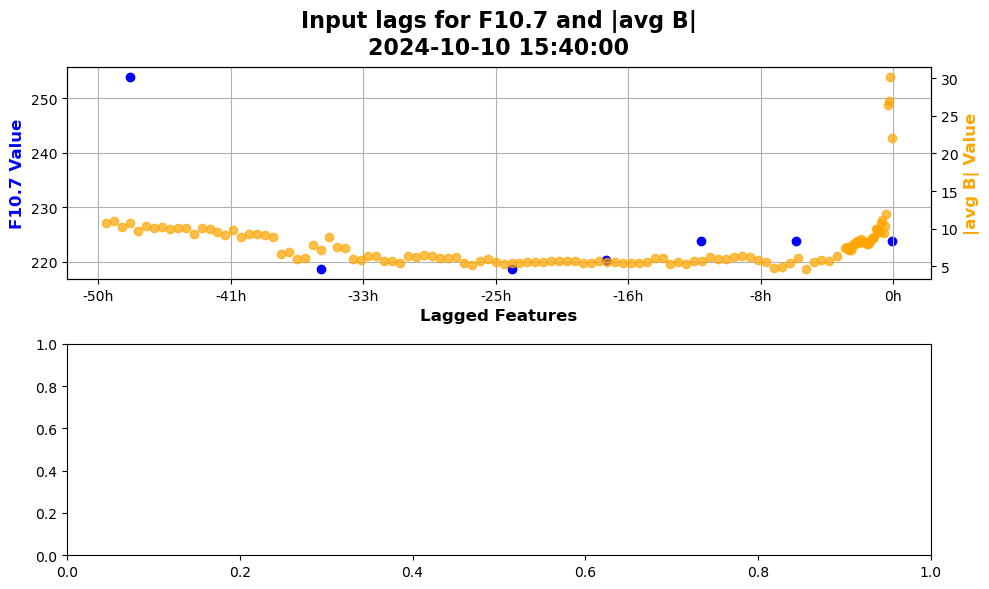

In [60]:
plot_forecast_for_event(
    predictions,
    time='2024-10-10 15:40:00',
    target='trend',
    alpha=0.1
)